In [4]:
# BigMart Sales Prediction
# Análise e previsão de vendas com Machine Learning

# O BigMart é uma rede de supermercados que coletou dados de vendas de 2013. 
# O objetivo é prever o volume de vendas de cada produto em cada loja — permitindo otimizar estoque, reduzir desperdício 
# e evitar perda de venda por falta de produto

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [12]:
## Etapa 1 — Carregar os dados

# Primeira etapa de qualquer projeto de dados: entender o que temos.

# - Quantas linhas e colunas?
# - Quais são os tipos de cada variável?
# - Existem valores faltantes?

# O dataset tem **8.523 linhas** e **12 colunas**, sendo cada linha 
# a combinação de um produto com uma loja específica.

# Foram identificados valores faltantes em duas colunas:
# - `Item_Weight` — 1.463 registros (17% do total)
# - `Outlet_Size` — 2.410 registros (28% do total)

# Esses problemas foram tratados na Etapa 3.

In [8]:
df = pd.read_csv('../data/Train.csv')
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dimensões: 8523 linhas × 12 colunas


In [5]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [9]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [13]:
## Etapa 2 — Análise Exploratória (EDA)
## Histograma para entender como estão distribuídas as vendas 
### Distribuição do target — Item_Outlet_Sales

# Histograma para entender como estão distribuídas as vendas, o valor que queremos prever.

# A distribuição apresenta assimetria positiva (cauda à direita): 
# A maioria dos produtos vende pouco, mas alguns poucos vendem muito acima da média, puxando-a para cima.

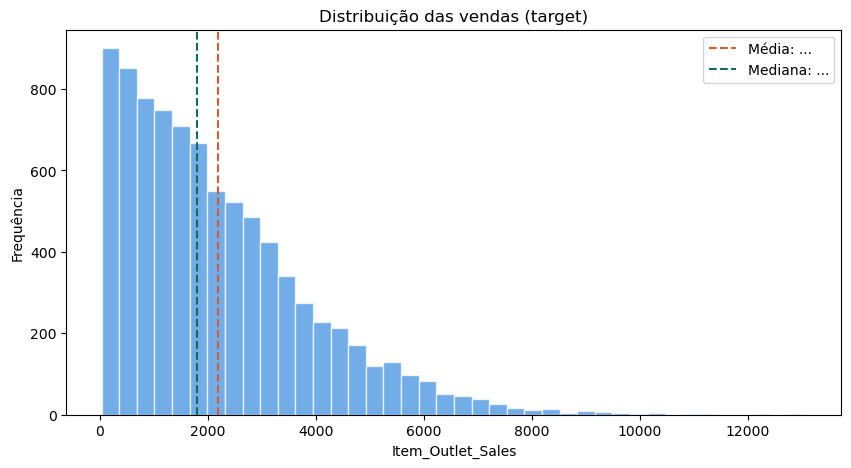

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df['Item_Outlet_Sales'], bins = 40,color='#378ADD', alpha=0.7, edgecolor='white')
plt.axvline(df['Item_Outlet_Sales'].mean(), color='#D85A30', linestyle='--', label=f"Média: ...")
plt.axvline(df['Item_Outlet_Sales'].median(), color='#0F6E56', linestyle='--', label=f"Mediana: ...")
plt.title('Distribuição das vendas (target)')
plt.xlabel('Item_Outlet_Sales')
plt.ylabel('Frequência')
plt.legend()
plt.show()

In [9]:
### Confirmando os valores numericamente

print(f"Média:       {df['Item_Outlet_Sales'].mean():.2f}")
print(f"Mediana:     {df['Item_Outlet_Sales'].median():.2f}")
print(f"Assimetria:  {df['Item_Outlet_Sales'].skew():.3f}")

Média:       2181.29
Mediana:     1794.33
Assimetria:  1.178


In [11]:
## A assimetria de 1.178 confirma a cauda à direita — valores acima de zero indicam assimetria positiva. A diferença de 
# R$387 entre média e mediana reforça que a mediana representa melhor o produto típico do BigMart.

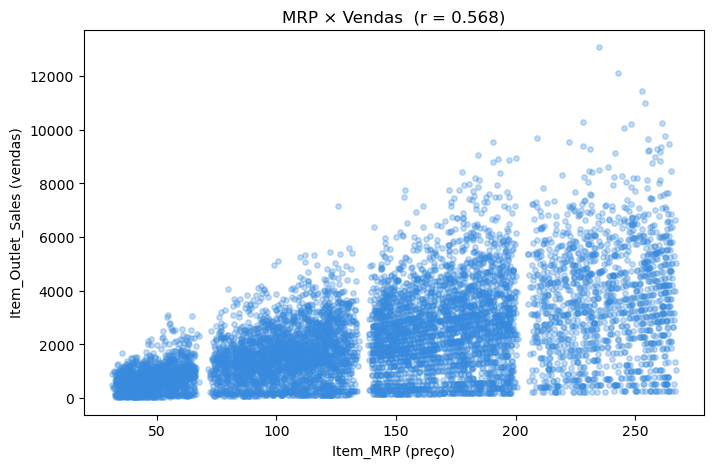

In [13]:
### Observação

# Correlação positiva moderada (r = 0.568) — confirmada visualmente pelo scatter plot. 
# Os dados se agrupam em faixas de preço definidas, sugerindo que o BigMart trabalha com categorias de preço estruturadas 
# (baixo, médio, alto e premium).

plt.figure(figsize=(8, 5))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.3, color='#378ADD', s=15)
plt.title(f"MRP × Vendas  (r = {df['Item_MRP'].corr(df['Item_Outlet_Sales']):.3f})")
plt.xlabel('Item_MRP (preço)')
plt.ylabel('Item_Outlet_Sales (vendas)')
plt.show()

<Figure size 1000x500 with 0 Axes>

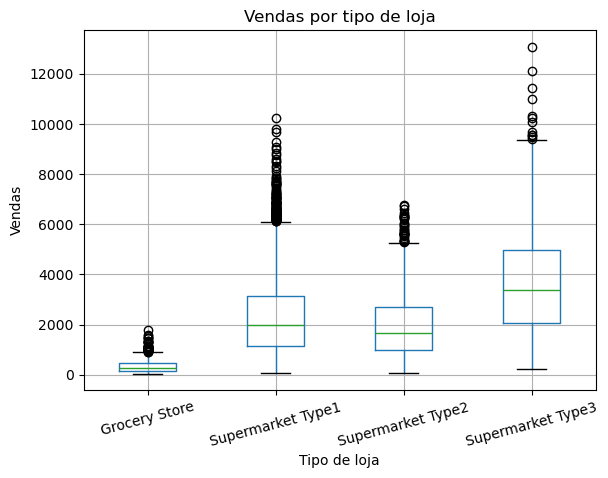

In [10]:
### Vendas por tipo de loja

# Boxplot para comparar a distribuição de vendas entre os diferentes tipos de loja.

# A hipótese é que o tipo de loja impacta diretamente o volume de vendas — Grocery Stores atendem menos clientes que 
# Supermarkets de grande porte.

plt.figure(figsize=(10, 5))
df.boxplot(column='Item_Outlet_Sales', by='Outlet_Type')
plt.title('Vendas por tipo de loja')
plt.suptitle('')
plt.xlabel('Tipo de loja')
plt.ylabel('Vendas')
plt.xticks(rotation=15)
plt.show()

In [14]:
### Observação

# A análise confirmou a hipótese, o tipo de loja tem impacto direto no volume de vendas.

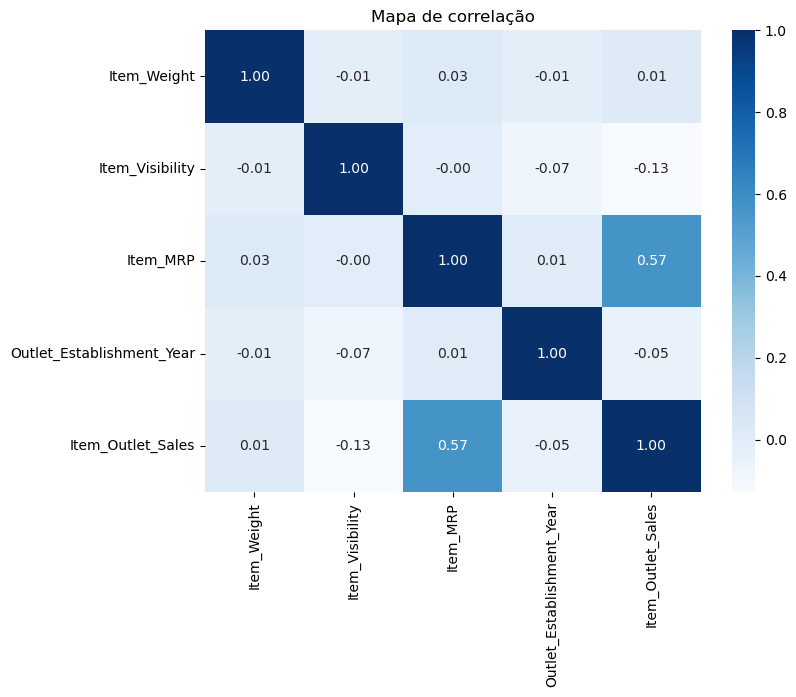

In [15]:
### Mapa de correlação entre variáveis numéricas

# Heatmap para visualizar a correlação entre todas as variáveis numéricas do dataset de uma vez.

# Correlação de Pearson varia de -1 a +1:
# - Próximo de 1 → relação positiva forte
# - Próximo de 0 → sem relação linear
# - Próximo de -1 → relação negativa forte

num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 
            'Outlet_Establishment_Year', 'Item_Outlet_Sales']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Mapa de correlação')
plt.show()

In [1]:
## Observação

# - `Item_MRP` tem a maior correlação com as vendas (r = 0.57)
# - `Item_Visibility` tem correlação levemente negativa (-0.13), produtos mais visíveis não necessariamente vendem mais
# - `Item_Weight` e `Outlet_Establishment_Year` têm correlação próxima de zero com as vendas — pouca influência direta

In [18]:
## Etapa 3 — Limpeza dos dados

# A EDA identificou quatro problemas que precisam ser resolvidos antes de treinar qualquer modelo:

# 1. `Item_Fat_Content` — 5 formas para representar 2 categorias
# 2. `Item_Weight` — 17% de valores faltantes
# 3. `Outlet_Size` — 28% de valores faltantes  
# 4. `Item_Visibility` — zeros que não fazem sentido

# Cada problema tem uma estratégia de tratamento diferente, baseada no tipo da variável e no comportamento esperado dos dados.

# Antes do inicio do tratamento, foi criada uma cópia do dataset

In [29]:
df_clean = df.copy()
print("Cópia criada!")

Cópia criada!


In [30]:
### Problema 1 — Item_Fat_Content inconsistente

# A coluna tinha 5 categorias diferentes para representar apenas 2 valores: Low Fat e Regular.

# Categorias encontradas: Low Fat, LF, low fat, Regular, reg

# Solução foi fazer a padronização desses valores.

print(df_clean['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [31]:
fat_map = {
    'LF':       'Low Fat',
    'low fat':  'Low Fat',
    'Low Fat':  'Low Fat',
    'reg':      'Regular',
    'Regular':  'Regular'
}

df_clean['Item_Fat_Content'] = df_clean['Item_Fat_Content'].map(fat_map)

print(df_clean['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [32]:
peso_por_tipo = df_clean.groupby('Item_Type')['Item_Weight'].mean()
print(peso_por_tipo)

# A tabela abaixo confirma que cada tipo de produto tem um peso médio característico — justificando a decisão de imputar 
# pela média do grupo em vez da média geral.

Item_Type
Baking Goods             12.277108
Breads                   11.346936
Breakfast                12.768202
Canned                   12.305705
Dairy                    13.426069
Frozen Foods             12.867061
Fruits and Vegetables    13.224769
Hard Drinks              11.400328
Health and Hygiene       13.142314
Household                13.384736
Meat                     12.817344
Others                   13.853285
Seafood                  12.552843
Snack Foods              12.987880
Soft Drinks              11.847460
Starchy Foods            13.690731
Name: Item_Weight, dtype: float64


In [33]:
### Aplicando a imputação

# Para cada linha com Item_Weight faltante, substituímos pelo peso médio do tipo de produto correspondente. Linhas com 
# valor preenchido são mantidas sem alteração.

df_clean['Item_Weight'] = df_clean.apply(
    lambda row: peso_por_tipo[row['Item_Type']] 
    if pd.isnull(row['Item_Weight']) 
    else row['Item_Weight'],
    axis=1
)

print(f"Faltantes em Item_Weight: {df_clean['Item_Weight'].isnull().sum()}")

Faltantes em Item_Weight: 0


In [34]:
### Problema 3 — Outlet_Size com valores faltantes

# 2.410 registros (28%) sem tamanho de loja registrado.

# Outlet_Size é uma variável categórica — não tem média. 
# A medida correta para categóricas é a moda (valor mais frequente).

# Estratégia: imputar pela moda do tipo de loja — cada tipo tem um tamanho predominante característico.

moda_por_tipo = df_clean.groupby('Outlet_Type')['Outlet_Size'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'Medium'
)
print(moda_por_tipo)

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object


In [35]:
df_clean['Outlet_Size'] = df_clean.apply(
    lambda row: moda_por_tipo[row['Outlet_Type']]
    if pd.isnull(row['Outlet_Size'])
    else row['Outlet_Size'],
    axis=1
)

print(f"Faltantes em Outlet_Size: {df_clean['Outlet_Size'].isnull().sum()}")

Faltantes em Outlet_Size: 0


In [36]:
### Problema 4 — Item_Visibility com zeros inválidos

# Um produto com visibilidade zero significa que não ocupa nenhum espaço na loja — impossível se ele está sendo vendido.

# Primeiro verificamos quantos registros têm esse problema.

### Aplicando a correção
   
print(f"Zeros em Item_Visibility: {(df_clean['Item_Visibility'] == 0).sum()}")

Zeros em Item_Visibility: 526


In [37]:
# Estratégia em duas etapas:
# 1. Substituir zeros por NaN — zero é um valor inválido, NaN representa ausência de dado corretamente
# 2. Imputar pela média de visibilidade do tipo de produto

# O motivo de converter para NaN antes: se mantivéssemos os zeros, eles entrariam no cálculo da média e distorceriam 
# o resultado para baixo.


df_clean['Item_Visibility'] = df_clean['Item_Visibility'].replace(0, np.nan)

vis_por_tipo = df_clean.groupby('Item_Type')['Item_Visibility'].mean()

df_clean['Item_Visibility'] = df_clean.apply(
    lambda row: vis_por_tipo[row['Item_Type']]
    if pd.isnull(row['Item_Visibility'])
    else row['Item_Visibility'],
    axis=1
)

print(f"Zeros em Item_Visibility: {(df_clean['Item_Visibility'] == 0).sum()}")
print(f"Faltantes em Item_Visibility: {df_clean['Item_Visibility'].isnull().sum()}")

Zeros em Item_Visibility: 0
Faltantes em Item_Visibility: 0


In [38]:
### Verificação final da limpeza

print("Faltantes após limpeza:")
print(df_clean.isnull().sum())

Faltantes após limpeza:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [39]:
## Etapa 4 — Feature Engineering

# Criação de novas variáveis a partir das existentes, informações que o modelo não consegue extrair sozinho.

# 1. `Outlet_Age` — anos de operação da loja (2013 − ano de abertura)


In [40]:
df_clean['Outlet_Age'] = 2013 - df_clean['Outlet_Establishment_Year']
print(df_clean['Outlet_Age'].describe())

count    8523.000000
mean       15.168133
std         8.371760
min         4.000000
25%         9.000000
50%        14.000000
75%        26.000000
max        28.000000
Name: Outlet_Age, dtype: float64


In [41]:
# 2. `Item_Visibility_Relative` — visibilidade do produto comparada à média da loja onde está
# O problema com a visibilidade original: 0.016 numa loja grande é diferente de 0.016 numa loja pequena.

# O que importa é se o produto está mais ou menos visível comparado aos outros produtos daquela loja específica.

# - Valor > 1 → produto mais visível que a média da loja
# - Valor < 1 → produto menos visível que a média da loja
# - Valor = 1 → exatamente na média

df_clean['Item_Visibility_Relative'] = (
    df_clean['Item_Visibility'] /
    df_clean.groupby('Outlet_Identifier')['Item_Visibility'].transform('mean')
)

print(df_clean['Item_Visibility_Relative'].describe())

count    8523.000000
mean        1.000000
std         0.643371
min         0.054653
25%         0.483730
50%         0.888467
75%         1.365147
max         2.960548
Name: Item_Visibility_Relative, dtype: float64


In [42]:
### Feature 3 — Item_Category

# Os dois primeiros caracteres do código do produto indicam a categoria:

# - `FD` → Food (alimentos)
# - `DR` → Drinks (bebidas)
# - `NC` → Non-Consumable (não consumíveis)

#Extraído diretamente do Item_Identifier usando fatiamento de string — str[:2].

df_clean['Item_Category'] = df_clean['Item_Identifier'].str[:2]
print(df_clean['Item_Category'].value_counts())

Item_Category
FD    6125
NC    1599
DR     799
Name: count, dtype: int64


In [43]:
### Ajuste — produtos não consumíveis

# Produtos da categoria NC (Non-Consumable) não deveriam ter classificação de gordura (Low Fat ou Regular) não faz sentido 
# para um produto de limpeza.

df_clean.loc[df_clean['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
print(df_clean['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64


In [44]:
print(f"Features originais:        {df.shape[1]}")
print(f"Features após engineering: {df_clean.shape[1]}")
print()
print("Novas features criadas:")
print("- Outlet_Age")
print("- Item_Visibility_Relative")
print("- Item_Category")

Features originais:        12
Features após engineering: 15

Novas features criadas:
- Outlet_Age
- Item_Visibility_Relative
- Item_Category


In [45]:
## Etapa 5 — Preparação para o modelo

# Dois passos antes de treinar:

# 1. Encoding de variáveis categóricas
# Modelos de ML trabalham apenas com números. As variáveis categóricas foram convertidas usando Label Encoding, cada 
# categoria vira um número inteiro.

# 2. Divisão treino e teste
# 80% dos dados para treino (6.818 amostras) e 20% para teste (1.705 amostras). O modelo nunca vê os dados de teste antes 
# de ser avaliado — garantindo uma medição real de performance.

# O target `Item_Outlet_Sales` recebeu transformação logarítmica (`log1p`) para reduzir a assimetria identificada na EDA.


In [46]:
features = ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 
            'Item_Visibility_Relative', 'Item_Type', 'Item_MRP', 
            'Outlet_Age', 'Outlet_Size', 'Outlet_Location_Type', 
            'Outlet_Type', 'Item_Category']

print(f"Total de features: {len(features)}")
print(features)

Total de features: 11
['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Visibility_Relative', 'Item_Type', 'Item_MRP', 'Outlet_Age', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']


In [47]:
### Encoding das variáveis categóricas

# Convertendo cada variável categórica em números inteiros usando Label Encoding.

# Exemplo: Outlet_Size → Small=2, Medium=1, High=0

from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

le = LabelEncoder()

cat_cols = df_model[features].select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f"{col}: {df_model[col].unique()}")

Item_Fat_Content: [0 2 1]
Item_Type: [ 4 14 10  6  9  0 13  5  2  8  7  3  1 15 11 12]
Outlet_Size: [1 2 0]
Outlet_Location_Type: [0 2 1]
Outlet_Type: [1 2 0 3]
Item_Category: [1 0 2]


In [52]:
### Separando features e target

# `X` — matriz com as 11 features que o modelo vai usar para aprender.  
# `y` — target com transformação logarítmica aplicada.

# A transformação `log1p` comprime os valores altos e deixa a distribuição mais simétrica, reduzindo o impacto dos 
#valores extremos no treinamento.

X = df_model[features]
y = np.log1p(df_model['Item_Outlet_Sales'])

print(f"X (features): {X.shape}")
print(f"y (target):   {y.shape}")
print(f"\nPrimeiros valores do target original: {df_model['Item_Outlet_Sales'].head().values}")
print(f"Primeiros valores do target com log:  {y.head().values.round(3)}")

X (features): (8523, 11)
y (target):   (8523,)

Primeiros valores do target original: [3735.138   443.4228 2097.27    732.38    994.7052]
Primeiros valores do target com log:  [8.226 6.097 7.649 6.598 6.903]


In [53]:
### Divisão treino e teste

# 80% dos dados para treino e 20% para teste.

# O modelo nunca vê os dados de teste antes de ser avaliado, simula dados novos do mundo real. Sem essa separação não 
# conseguimos medir se o modelo realmente aprendeu ou apenas decorou os dados de treino (overfitting).

# `random_state=42` garante que a divisão seja sempre a mesma, reprodutibilidade do experimento.


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino:  {X_train.shape[0]} amostras")
print(f"Teste:   {X_test.shape[0]} amostras")

Treino:  6818 amostras
Teste:   1705 amostras


In [54]:
## Etapa 6 — Treinamento dos modelos

# Dois modelos foram treinados e comparados:

# Modelo 1 — Regressão Linear (baseline)  
# Ponto de partida. Simples e interpretável, cada coeficiente tem significado direto. Serve de referência para medir 
# a melhora dos modelos seguintes.

## Modelo 2 — Random Forest 
# Ensemble de 100 árvores de decisão. Captura relações não-lineares que a regressão linear não consegue expressar.

In [55]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


In [56]:
### Avaliação dos modelos

# Função criada para calcular três métricas em cada modelo:

# R² — percentual da variação nas vendas explicado pelo modelo
# RMSE — erro médio em unidades de venda (mesma escala do target)
# MAE — erro absoluto médio

# As previsões são convertidas de volta para a escala original (`expm1`) antes de calcular as métricas, para interpretar 
# os erros em valores reais de venda.

def avaliar(nome, y_real, y_pred):
    y_r = np.expm1(y_real)
    y_p = np.expm1(y_pred)
    r2   = r2_score(y_r, y_p)
    rmse = np.sqrt(mean_squared_error(y_r, y_p))
    mae  = mean_absolute_error(y_r, y_p)
    print(f"{nome}")
    print(f"  R²:   {r2:.4f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE:  {mae:,.2f}")
    return r2, rmse, mae

print("REGRESSÃO LINEAR")
print("Treino:")
avaliar("", y_train, lr.predict(X_train))
print("Teste:")
avaliar("", y_test, lr.predict(X_test))

REGRESSÃO LINEAR
Treino:

  R²:   0.4656
  RMSE: 1,257.27
  MAE:  881.02
Teste:

  R²:   0.4952
  RMSE: 1,171.30
  MAE:  818.07


(0.4952362263542096, np.float64(1171.2953630411748), 818.0689429662084)

In [57]:
### Interpretação — Regressão Linear

# R² = 0.49 no teste — o modelo explica 49% da variação nas vendas. Razoável, mas indica que relações não-lineares 
# não estão sendo capturadas.
# RMSE = 1.171** — erro médio de R$1.171 por previsão.
# Gap treino × teste pequeno** — sem overfitting, mas o modelo é simples demais para capturar a complexidade dos dados.



In [60]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest treinado!")

Random Forest treinado!


In [61]:
### Teste de hiperparâmetro — n_estimators

# Testado com 100 e 200 árvores. A melhora foi minima (0.0005 no R²) com o dobro do tempo de treino.

# Conclusão: 100 árvores é suficiente para esse dataset, o limite de performance está nos dados, não no modelo.

print("RANDOM FOREST")
print("Treino:")
avaliar("", y_train, rf.predict(X_train))
print("Teste:")
r2_rf, rmse_rf, mae_rf = avaliar("", y_test, rf.predict(X_test))

RANDOM FOREST
Treino:

  R²:   0.7224
  RMSE: 906.16
  MAE:  609.11
Teste:

  R²:   0.5773
  RMSE: 1,071.88
  MAE:  737.40


In [39]:
## Etapa 7 — Avaliação visual

# Análise gráfica dos resultados para entender onde cada modelo acerta e onde erra.

## Dois gráficos foram gerados:

# 1. Real vs Previsto
# Pontos próximos da linha diagonal vermelha indicam previsões precisas. Dispersão indica erro.

# 2. Importância das features
# Quais variáveis o Random Forest considerou mais relevantes para fazer as previsões.

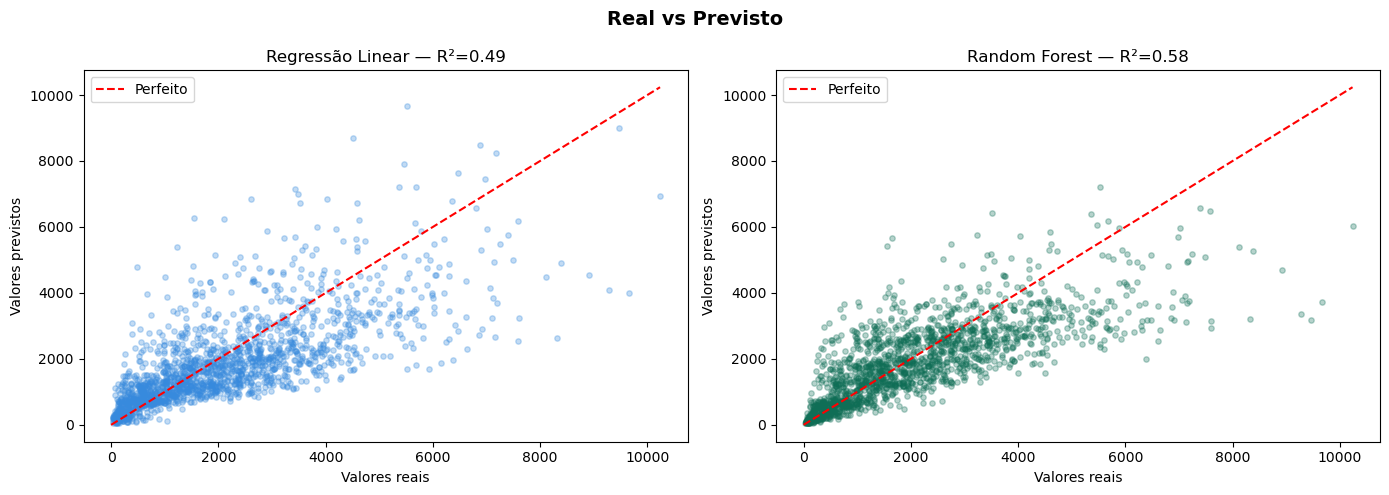

In [62]:
### Gráfico 1 — Real vs Previsto

# A linha vermelha tracejada representa a previsão perfeita, onde valor real = valor previsto.

# Quanto mais próximos os pontos estiverem da linha, melhor o modelo. Dispersão indica erro.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Real vs Previsto', fontsize=14, fontweight='bold')

y_test_orig = np.expm1(y_test)
pred_lr     = np.expm1(lr.predict(X_test))
pred_rf     = np.expm1(rf.predict(X_test))
max_val     = max(y_test_orig.max(), pred_rf.max())

for ax, pred, title, color in [
    (axes[0], pred_lr, f'Regressão Linear — R²=0.49', '#378ADD'),
    (axes[1], pred_rf, f'Random Forest — R²=0.58',    '#0F6E56')]:
    ax.scatter(y_test_orig, pred, alpha=0.3, color=color, s=15)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfeito')
    ax.set_title(title)
    ax.set_xlabel('Valores reais')
    ax.set_ylabel('Valores previstos')
    ax.legend()

plt.tight_layout()
plt.show()


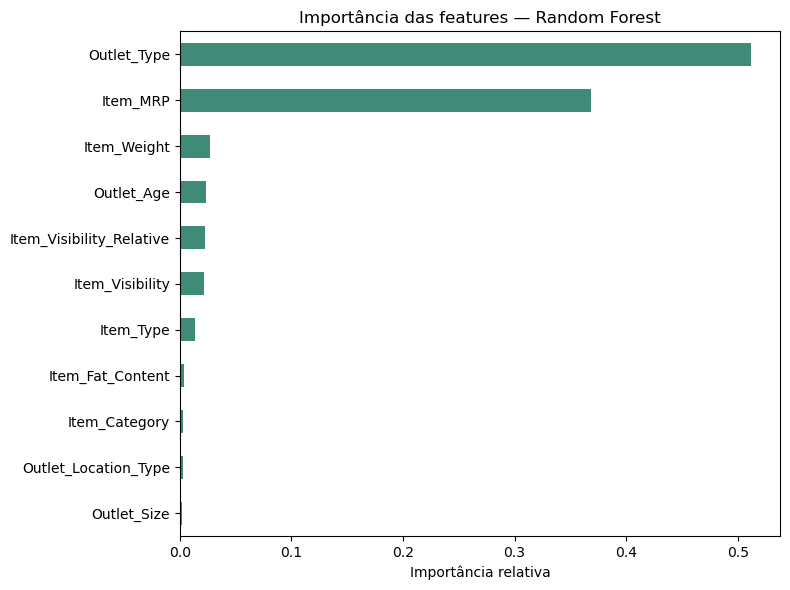

In [42]:
### Observação

# O Random Forest apresenta menor dispersão em torno da linha perfeita, confirmando a melhora nas métricas.

# Ambos os modelos erram mais na faixa de valores altos (acima de R$6.000), produtos que vendem muito são os 
# casos mais difíceis de prever, por serem mais raros no dataset.

importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='#0F6E56', alpha=0.8)
plt.title('Importância das features — Random Forest')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

In [46]:
## Etapa 8 — Conclusões

### O que aprendi com os dados

#Este foi meu primeiro projeto de Machine Learning desenvolvido de ponta a ponta. A análise mostrou que o tipo de loja 
#(Outlet_Type) e o preço máximo do produto (Item_MRP) são as 
# variáveis com maior impacto nas vendas, respondendo por quase 90% da importância do modelo.

### Decisões de limpeza

#O dataset apresentou dois problemas principais: 17% de valores faltantes em Item_Weight e 28% em Outlet_Size. A estratégia 
#foi imputar Item_Weight pela média do tipo de produto e Outlet_Size pela moda do tipo de loja — decisões baseadas no 
#comportamento esperado de cada grupo, não na média geral.

##Item_Fat_Content tinha 5 formas diferentes para representar apenas 2 categorias (Low Fat e Regular), corrigidas via 
# mapeamento direto.

### Resultado dos modelos

#| Modelo | R² | RMSE | MAE |
#|---|---|---|---|
#| Regressão Linear | 0.4952 | 1.171 | 818 |
#| Random Forest | 0.5773 | 1.071 | 737 |

#O Random Forest superou a regressão linear em todas as métricas, capturando relações não-lineares que a reta não consegue expressar.

### Onde o modelo erra mais

#O modelo apresenta maior dificuldade em prever vendas de produtos com valores altos — visível no gráfico Real vs Previsto, onde os 
#pontos se afastam mais da linha perfeita na faixa acima de R$6.000.